# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

# Rozwiązanie zadania 2

Aby ułatwić sobie rozwiązanie zadania, podzielę je na kilka części:

1. Wczytanie i przygotowanie danych -Wykorzystanie przygotowania z poprzedniego zadania `EDA_zadanie`
2. Podsumowanie poprzedniego zadania - wypisanie najważniejszych wniosków
3. Podział danych na zbiory treningowe i testowe
5. Dummy Classifier - ustalenie baseline'u do pobicia
6. Wybór i zastosowanie metryk oceny modeli
7. Wybór dwóch modeli uczenia maszynowego - standaryzacja dla jednego z nich
8. Badanie wpływu hiperparametrów na wyniki modeli
9. Porównanie modeli i analiza uzyskanych wyników
10. Podsumowanie i wnioski końcowe

# Importy


In [512]:
#imports:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, classification_report, f1_score
from sklearn import tree
import seaborn as sns
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Wczytanie i przygotowanie danych

In [513]:
#reading titanic data
titanic_data_path = Path('/content/drive/MyDrive/machine_learning/titanic.csv')
titanic_data = pd.read_csv(titanic_data_path)
titanic_data.drop(columns=['PassengerId','Ticket'],inplace=True)
titanic_data.head(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S
5,0,3,"Moran, Mr. James",male,NaN,0,0,8.4583,NaN,Q
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,51.8625,E46,S
7,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,21.0750,NaN,S
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,NaN,NaN,S
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,30.0708,NaN,C


# Wnioski z poprzedniego zadania:

Na podstawie wykresów można zauważyć że:

* Około 38% pasażerów przeżyło.
* Największa przeżywalność występuje w pierwszej klasie podróży.
* Kobiety mają znacznie wyższą przeżywalność niż mężczyźni.
* Wysoką przeżywalność można zauważyć u tytułów: Mrs, Miss, Master, które odpowiadają kobietom i chłopcom.
* Pasażerowie, którzy przeżyli, mają wyższą medianę ceny biletu oraz wyższe wartości kwartylowe. Sugeruje to, że większa szansa przeżycia jest powiązana z ceną biletu.

* W kontekście zadania kolumny `PassengerId` i `Ticket` nie są przydatne, można je usunać
* Z kolumn `Name`, `Cabin`, `SibSp`, `Parch` można wyciągnąć ciekawe informacje `FamilyMembers`, `Title` i `Deck`

# Podzielenie danych na zbiory testowe i treningowe
Do podzielenia danych specyzowałam `stratify=y`, aby proporcja między osobami, które przeżyły i które nie przeżyły, w setach train i test była taka sama.

In [514]:
x = titanic_data.drop(columns=['Survived'])
y = titanic_data['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2137,stratify=y)

Sprawdzenie braków x_train i x_test

In [515]:
x_train.isna().sum().sum()

np.int64(763)

In [516]:
x_test.isna().sum().sum()

np.int64(201)

# Uzupełnienie braków w danych

W fukcji process data musimy zwrócić uwagę na kilka rzeczy:
* Uporządkować `Titles`: Aby to zrobić, stworzymy listę 'akceptowalnych; tytułów, takich co występują w train set co najmniej 10 razy. Tytuły, które nie spełniają tego warunku zarówno w train i test set zostaną zmienione na 'Other'.
* Aby uniknąć data leakage w test set, braki w danych uzupełnimy bazując o train set.

In [517]:
def process_data(df_train, df_test):
  x_train = df_train.copy()
  x_test = df_test.copy()

  #creating addition columns
  for df in [x_train, x_test]:
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Cabin'] = df['Cabin'].fillna("Unknown")
    df['Deck'] = df['Cabin'].str[0]
    df['FamilySize'] = df['SibSp'] + df['Parch']
    #removing used columns
    df.drop(columns=['Name','Cabin','SibSp','Parch'],inplace=True)

  #cleaning up titles
  title_counts = x_train['Title'].value_counts()
  accepted_titles = title_counts[title_counts >= 10].index
  #jeżeli tytułu nie ma w acceptowalnej ilości w train set, zamień na 'other'
  x_train['Title'] = x_train['Title'].where(x_train['Title'].isin(accepted_titles), 'Other')
  x_test['Title'] = x_test['Title'].where(x_test['Title'].isin(accepted_titles), 'Other')

  #using only x_train to avoid data leakage
  most_common_embarked = x_train['Embarked'].mode()[0]
  median_fare_by_class = x_train.groupby('Pclass')['Fare'].median()
  median_age_by_title = x_train.groupby('Title')['Age'].median()

  for df in [x_train, x_test]:
    df['Embarked'] = df['Embarked'].fillna(most_common_embarked)
    df['Fare'] = df['Fare'].fillna(df['Pclass'].map(median_fare_by_class))
    df['Age'] = df['Age'].fillna(df['Title'].map(median_age_by_title))

    df['IsMale'] = df['Sex'].map({'male':1, 'female':0})
    df.drop(columns=['Sex'], inplace=True)

    df['Fare'] = np.log1p(df['Fare'])

  categorical_columns = ['Embarked','Title','Deck']
  x_train = pd.get_dummies(x_train, columns=categorical_columns)
  x_test = pd.get_dummies(x_test, columns=categorical_columns)

  x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

  return x_train, x_test

In [518]:
x_train_processed, x_test_processed = process_data(x_train, x_test)

In [519]:
x_train_processed.isna().sum().sum()

np.int64(0)

In [520]:
x_test_processed.isna().sum().sum()

np.int64(0)

# Dummy Classifier

In [521]:
dummy_model = DummyClassifier(strategy = 'most_frequent')
dummy_model.fit(x_train_processed, y_train)
y_pred = dummy_model.predict(x_test_processed)
print(classification_report(y_test, y_pred,zero_division=0))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179



array([[110,   0],
       [ 69,   0]])

Dummy Classifier przewiduje zawsze klasę najczęściej występującą w zbiorze
treningowym. Osiągnął 61% accuracy na zbiorze testowym. Jest to baseline, który chcemy przebić naszymi modelami.

# Dwa wybrane modele do wytrenowania:
* Decision Tree: spodobał mi się opis modelu jako intuicyjny i łatwy do zrozumienia. Też nie potrzebuje standaryzacji danych, aby osiągnąć dobre wyniki

* SVM: jest wrażliwy na standaryzacje danych, więc bedzie ciekawym casem do zrobienia eksperymentu, jak ustandaryzowanie danych wpływa na wynik modelu.

# Funkcja do ocenienia modeli
Do oceny modeli wykorzystuję następujące metryki:

* Accuracy - jaki procent wszystkich pasażerów został sklasyfikowany
poprawnie.

* Precision - jaki procent osób zaklasyfikowanych jako ocalałe rzeczywiście
przeżył.

* Recall - jak dużą część wszystkich ocalałych model potrafił wykryć.  Interesujący jest recall dla klasy 1. Pokazuje, jak dobrze model rozpoznaje osoby, które rzeczywiście przeżyły.

* F1-score  - łączy precision i recall, pozwala ocenić model pod kątem
obu tych wartości jednocześnie.

Dodatkowo wykorzystuję macierz pomyłek, aby pokazać, ile osób z każdej
klasy zostało sklasyfikowanych poprawnie i błędnie.


In [522]:
def evaluate_model(model, x_train, y_train, x_test, y_test, model_name):
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    print(model_name.upper())
    print("-------------------------------------------------")
    print("Accuracy trening:", accuracy_score(y_train, train_pred))
    print("Accuracy test:", accuracy_score(y_test, test_pred))

    print("\nRaport klasyfikacji:")
    print(classification_report(y_test, test_pred))

    print("Macierz pomyłek:")
    print(confusion_matrix(y_test, test_pred))

# Decision Tree

In [523]:
tree_model = tree.DecisionTreeClassifier(max_depth=3)
tree_model.fit(x_train_processed, y_train)
tree_y_pred = tree_model.predict(x_test_processed)

evaluate_model(tree_model, x_train_processed,y_train,x_test_processed,y_test,"decision tree")

DECISION TREE
-------------------------------------------------
Accuracy trening: 0.8230337078651685
Accuracy test: 0.8435754189944135

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       110
           1       0.87      0.70      0.77        69

    accuracy                           0.84       179
   macro avg       0.85      0.82      0.83       179
weighted avg       0.85      0.84      0.84       179

Macierz pomyłek:
[[103   7]
 [ 21  48]]


## Zbadanie hiperparametrów dla modelu Decision Tree
* `max_depth` -  określa maksymalną głębokość drzewa. Zbyt mała wartość może
spowodować niedouczenie modelu, natomiast zbyt duża może prowadzić
do przeuczenia.

* `min_samples_leaf` - określa minimalną liczbę obserwacji w liściu drzewa.
Zwiększenie tego parametru ogranicza złożoność modelu i może zmniejszyć
ryzyko overfittingu.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4,5,6,8, 10, 15, None],
    'min_samples_leaf': [1, 2,3, 5, 10, 15, 20],
}

tree_grid_search = GridSearchCV(
    tree.DecisionTreeClassifier(random_state=0),
    param_grid,
    cv=5,
    scoring='accuracy'
)

tree_grid_search.fit(x_train_processed, y_train)

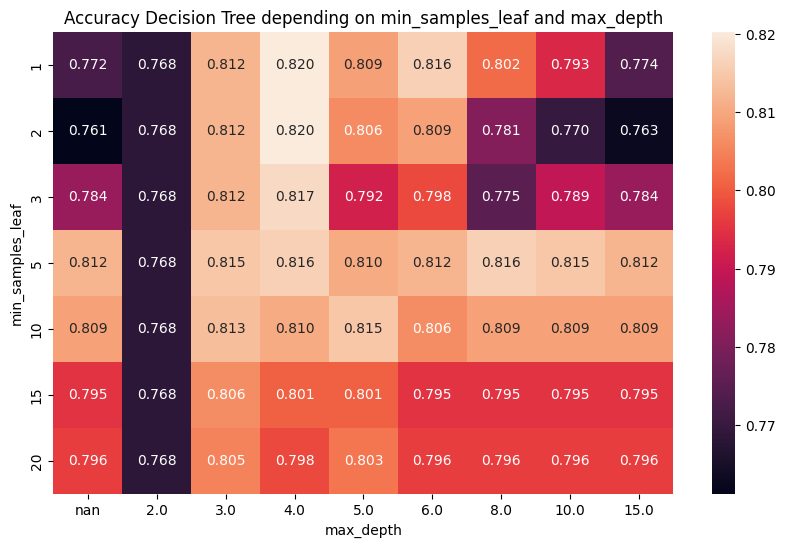

In [525]:
tree_table = pd.DataFrame(tree_grid_search.cv_results_)

tree_pivot_table = tree_table.pivot(
    index='param_min_samples_leaf',
    columns='param_max_depth',
    values='mean_test_score'
)

plt.figure(figsize=(10, 6))
sns.heatmap(tree_pivot_table, annot=True, fmt='.3f')
plt.title('Accuracy Decision Tree depending on min_samples_leaf and max_depth')
plt.xlabel('max_depth')
plt.ylabel('min_samples_leaf')
plt.show()

In [526]:
print("Najlepsze ustawienia:", tree_grid_search.best_params_)
print("Wynik cross-validation:", round(tree_grid_search.best_score_, 3))
print("Wynik na teście:", round(tree_grid_search.score(x_test_processed, y_test), 3))

Najlepsze ustawienia: {'max_depth': 4, 'min_samples_leaf': 1}
Wynik cross-validation: 0.82
Wynik na teście: 0.844


### Wnioski z badania Decision Tree

Badano wpływ parametrów `max_depth` oraz `min_samples_leaf`.

Najlepsze parametry zostały wybrane za pomocą 5-krotnej cross-validation.
Dla uzyskanych danych najlepsze okazały się wartości:
`max_depth = 4` oraz `min_samples_leaf = 1`.

Wynik cross-validation był podobny do wyniku uzyskanego na zbiorze
testowym, co sugeruje, że model nie został mocno przeuczony.

### Odpalenie Decision Tree dla najlepszych min_samples_leaf i max_depth

In [527]:
evaluate_model(tree_grid_search.best_estimator_, x_train_processed,y_train,x_test_processed,y_test,"best decision tree")

BEST DECISION TREE
-------------------------------------------------
Accuracy trening: 0.8412921348314607
Accuracy test: 0.8435754189944135

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88       110
           1       0.90      0.67      0.77        69

    accuracy                           0.84       179
   macro avg       0.86      0.81      0.82       179
weighted avg       0.85      0.84      0.84       179

Macierz pomyłek:
[[105   5]
 [ 23  46]]


### Wniosek
Decision Tree radzi sobie dobrze z klasyfikacją, szczególnie z rozpoznawaniem
osób, które nie przeżyły. Gorzej radzi sobie z wykrywaniem wszystkich
ocalałych, ponieważ recall dla klasy 1 wynosi 0.67

# SVM model

### Standaryzacja danych - jak  wpływa na wynik modelu
Aby to sprawdzić, najpierw odpalę model SVM na niestandaryzowanych danych.

In [528]:
svm_model_not_scaled = SVC(C=1, gamma=0.1)
svm_model_not_scaled.fit(x_train_processed, y_train)
svm_y_pred = svm_model_not_scaled.predict(x_test_processed)

evaluate_model(svm_model_not_scaled, x_train_processed,y_train,x_test_processed,y_test,"svm without scaled data")

SVM WITHOUT SCALED DATA
-------------------------------------------------
Accuracy trening: 0.8637640449438202
Accuracy test: 0.8379888268156425

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       110
           1       0.83      0.72      0.78        69

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.82       179
weighted avg       0.84      0.84      0.84       179

Macierz pomyłek:
[[100  10]
 [ 19  50]]


Odpalenie modelu na ustandaryzowanych danych:

In [529]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_processed)
x_test_scaled = scaler.transform(x_test_processed)

In [530]:
svm_model = SVC(C=1, gamma=0.1)
svm_model.fit(x_train_scaled, y_train)
svm_scaled_y_pred = svm_model.predict(x_test_scaled)

evaluate_model(svm_model, x_train_scaled,y_train,x_test_scaled,y_test,"svm with scaled data")

SVM WITH SCALED DATA
-------------------------------------------------
Accuracy trening: 0.8539325842696629
Accuracy test: 0.8659217877094972

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       110
           1       0.91      0.72      0.81        69

    accuracy                           0.87       179
   macro avg       0.88      0.84      0.85       179
weighted avg       0.87      0.87      0.86       179

Macierz pomyłek:
[[105   5]
 [ 19  50]]


### Wniosek

Standaryzacja danych poprawiła działanie modelu SVM. Accuracy wzrosło
z około 84% do około 87%.

SVM jest wrażliwy na skalę cech, dlatego standaryzacja pozwala mu lepiej
wyznaczyć granicę pomiędzy klasami. W dalszej części hiperparametry SVM badane są na ustandaryzowanych danych.

## Zbadanie hiperparametrów dla modelu SVM

* Parametr `C` określa karę za błędną klasyfikację. Większe wartości pozwalają
modelowi mocniej dopasować się do danych treningowych.

* Parametr `gamma` wpływa na złożoność granicy decyzyjnej. Małe wartości
prowadzą do prostszej granicy, natomiast większe wartości mogą pozwolić
modelowi lepiej dopasować się do szczegółów danych.

In [ ]:
from sklearn.model_selection import GridSearchCV

svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1]
}

svm_grid_search = GridSearchCV(
    SVC(),
    svm_param_grid,
    cv=5,
    scoring='accuracy'
)

svm_grid_search.fit(x_train_scaled, y_train)

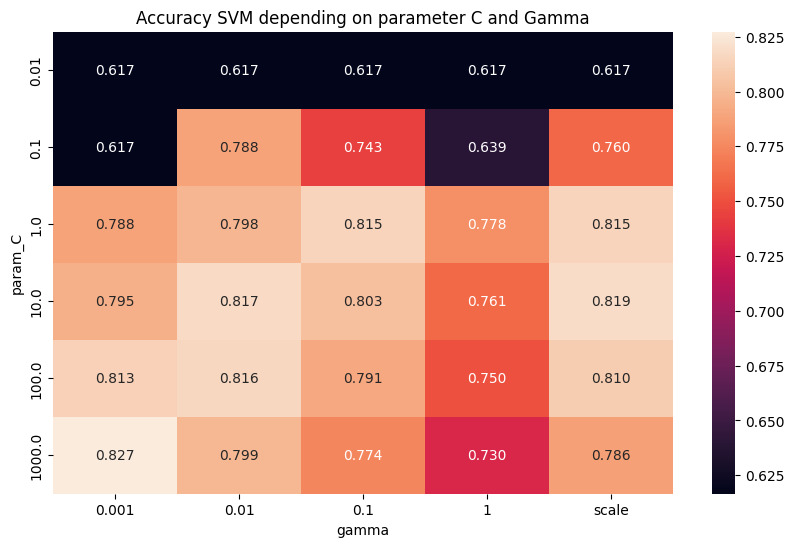

In [532]:
svm_table = pd.DataFrame(svm_grid_search.cv_results_)

svm_pivot_table = svm_table.pivot(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

plt.figure(figsize=(10, 6))
sns.heatmap(svm_pivot_table, annot=True, fmt='.3f')
plt.title('Accuracy SVM depending on parameter C and Gamma')
plt.xlabel('gamma')
plt.ylabel('param_C')
plt.show()

In [533]:
print("Najlepsze ustawienia:", svm_grid_search.best_params_)
print("Wynik cross-validation:", round(svm_grid_search.best_score_, 3))
print("Wynik na teście:", round(svm_grid_search.score(x_test_scaled, y_test), 3))

Najlepsze ustawienia: {'C': 1000, 'gamma': 0.001}
Wynik cross-validation: 0.827
Wynik na teście: 0.877


### Wnioski z badania SVM

Badano wpływ parametrów `C` oraz `gamma`.

Najlepsze parametry zostały wybrane za pomocą 5-krotnej cross-validation. Dla uzyskanych danych najlepsze okazały się wartości: `C = 1000` oraz `gamma = 0.001`.

Uzyskany wynik cross-validation powinien być porównany z wynikiem na
zbiorze testowym. Niewielka różnica pomiędzy tymi wynikami oznacza,
że model dobrze generalizuje na nowe dane.

### Odpalenie SVM dla najlepszych C - Gamma

In [534]:
evaluate_model(svm_grid_search.best_estimator_, x_train_scaled,y_train,x_test_scaled,y_test,"best svm")

BEST SVM
-------------------------------------------------
Accuracy trening: 0.851123595505618
Accuracy test: 0.8770949720670391

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       110
           1       0.89      0.78      0.83        69

    accuracy                           0.88       179
   macro avg       0.88      0.86      0.87       179
weighted avg       0.88      0.88      0.88       179

Macierz pomyłek:
[[103   7]
 [ 15  54]]


### Wniosek

SVM radzi sobie dobrze z rozpoznawaniem obu klas. Podobnie jak Decision
Tree, znacznie lepiej rozpoznaje osoby, które nie przeżyły, niż wszystkie
osoby, które przeżyły. Accuracy na poziomie około 84% jest zdecydowanie
lepsze od wyniku Dummy Classifier wynoszącego około 61%.

# Podsumowanie

In [535]:
comparison = pd.DataFrame({
    'Model': [
        'Dummy Classifier',
        'Decision Tree',
        'SVM'
    ],
    'Accuracy test': [
        accuracy_score(y_test, dummy_model.predict(x_test_processed)),
        accuracy_score(y_test, tree_grid_search.best_estimator_.predict(x_test_processed)),
        accuracy_score(y_test, svm_grid_search.best_estimator_.predict(x_test_scaled))
    ],
    'F1 test': [
        f1_score(y_test, dummy_model.predict(x_test_processed)),
        f1_score(y_test, tree_grid_search.best_estimator_.predict(x_test_processed)),
        f1_score(y_test, svm_grid_search.best_estimator_.predict(x_test_scaled))
    ]
})

comparison.round(3)

,Model,Accuracy test,F1 test
0,Dummy Classifier,0.615,0.000
1,Decision Tree,0.844,0.767
2,SVM,0.877,0.831


# Podsumowanie i wnioski końcowe

W zadaniu porównano trzy klasyfikatory: Dummy Classifier, Decision Tree
oraz SVM.

Dummy Classifier osiągnął około 61% accuracy i stanowił punkt odniesienia
dla pozostałych modeli. Oba właściwe modele osiągnęły znacznie lepsze
wyniki, dzięki czemu spełniły założenie dotyczące pokonania baseline'u.

Dla Decision Tree badano parametry `max_depth` oraz `min_samples_leaf`.
Pozwoliło to znaleźć model o odpowiedniej złożoności i ograniczyć ryzyko
overfittingu.

Dla SVM badano parametry `C` oraz `gamma`. Najlepszy model SVM osiągnął
lepszy wynik na zbiorze testowym niż Decision Tree.

Istotnym wnioskiem jest również wpływ standaryzacji. W przypadku SVM
standaryzacja poprawiła accuracy z około 84% do około 87%, dlatego
w dalszych eksperymentach wykorzystano ustandaryzowane dane.

Najlepszym z badanych modeli okazał się SVM. Osiągnął około 88% accuracy
na zbiorze testowym, podczas gdy Decision Tree osiągnął około 84%,
a Dummy Classifier około 61%.

Za dobry wynik można uznać taki, który wyraźnie przewyższa baseline,
a jednocześnie utrzymuje podobną jakość na danych treningowych
i testowych.